In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### read zomato dataset 

In [11]:
zomato_df = pd.read_csv("/Users/tulspal/Downloads/Zomato-data-.csv")
print(zomato_df.head())

                    name online_order book_table   rate  votes  \
0                  Jalsa          Yes        Yes  4.1/5    775   
1         Spice Elephant          Yes         No  4.1/5    787   
2        San Churro Cafe          Yes         No  3.8/5    918   
3  Addhuri Udupi Bhojana           No         No  3.7/5     88   
4          Grand Village           No         No  3.8/5    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


### remove denominator from rate column

In [12]:
zomato_df['rate'] = zomato_df['rate'].str.split('/').str[0].astype(float)


In [43]:
zomato_df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


### Summery of dataframe

In [14]:
zomato_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


### There is no Null value in dataframe


Text(0.5, 0, 'Type of Restaurants')

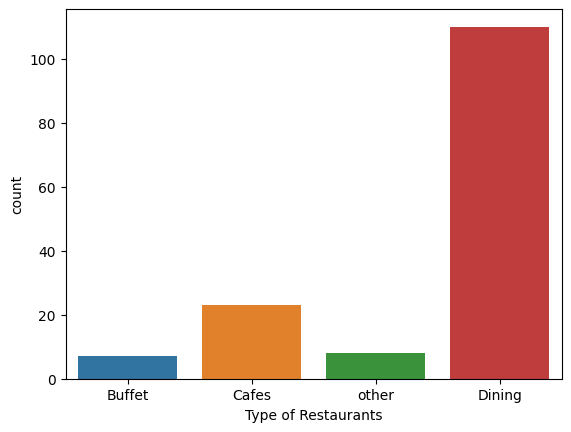

In [33]:
#explore the listed_in(type) column

sns.countplot(x=zomato_df['listed_in(type)'],hue=zomato_df['listed_in(type)'], legend=False)
plt.xlabel("Type of Restaurants")

##Conclusion the majority of the restaurants fall into the dining category

Text(0, 0.5, 'votes')

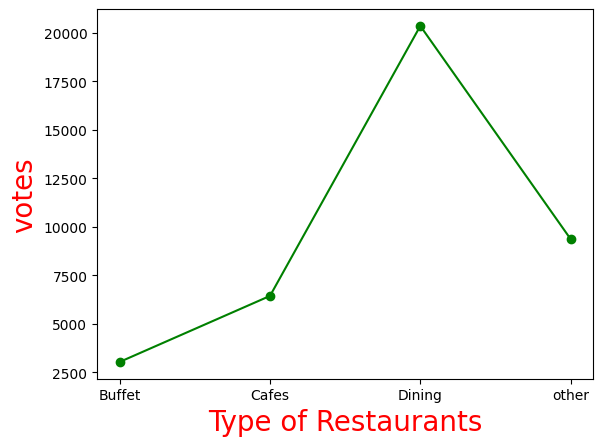

In [40]:
grouped_data = zomato_df.groupby('listed_in(type)')['votes'].sum()
result = pd.DataFrame({'votes': grouped_data})
plt.plot(result, c='green', marker='o')
plt.xlabel('Type of Restaurants', c='red', size=20)
plt.ylabel('votes', c='red', size=20)

### Dining restaurants are preferred by more individuals

### Determine the restaurant's name that received the maximum votes

In [41]:
max_votes = zomato_df['votes'].max()
restaurants_with_max_votes = zomato_df.loc[zomato_df['votes'] == max_votes,'name']

print("resturants with maximum votes:")
print(restaurants_with_max_votes)


resturants with maximum votes:
38    Empire Restaurant
Name: name, dtype: object


In [42]:
zomato_df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


<Axes: xlabel='online_order', ylabel='count'>

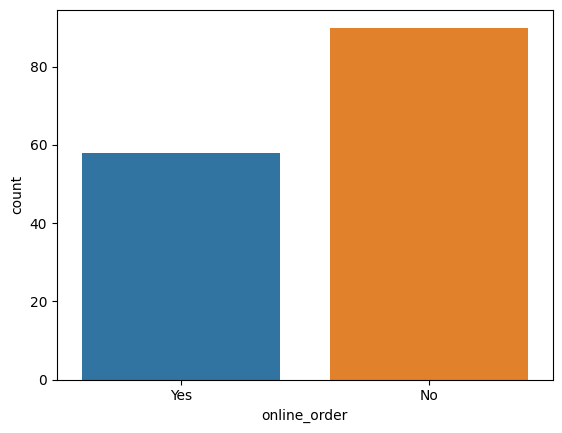

In [46]:
#explore the online_order column
sns.countplot(x=zomato_df['online_order'],hue=zomato_df['online_order'],legend=False)

### Conclusion: Majority of restaurants do not accept online order.

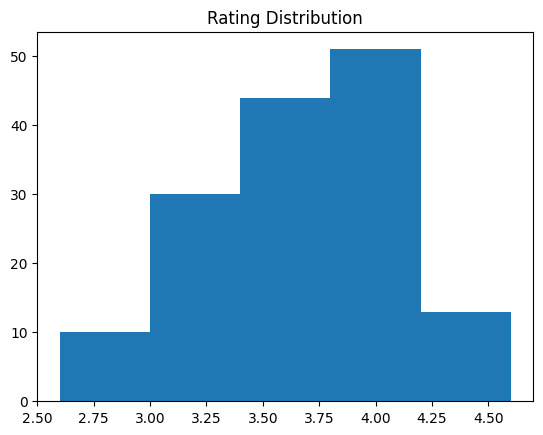

In [51]:
plt.hist(zomato_df['rate'],bins=5)
plt.title('Rating Distribution')
plt.show()

### The majority of restaurants recevied rating between 3.5 to 4.

<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

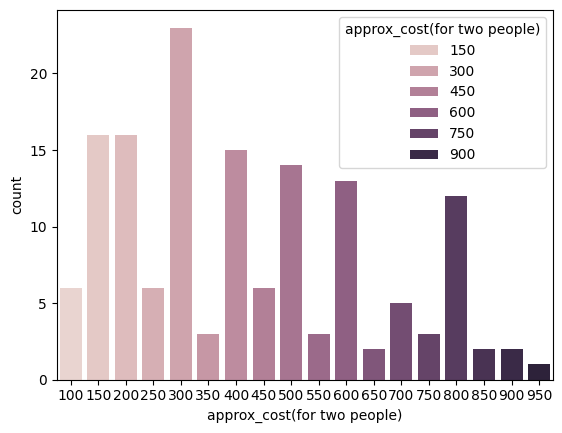

In [55]:
# lets explore the approx cost for two people column.
couple_data = zomato_df['approx_cost(for two people)']
sns.countplot(x=couple_data,hue=zomato_df['approx_cost(for two people)'])


### This suggests that majority of couple prefer restaurants with an approximate cost of 300 rupees.

<Axes: xlabel='online_order', ylabel='rate'>

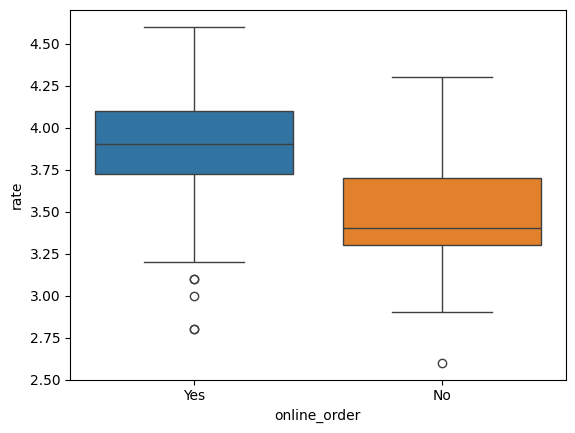

In [58]:
#lets explore rate again to see whether online order receive higher rating than offline orders.
plt.Figure(figsize= (6,6))
sns.boxplot(x='online_order',y='rate', data= zomato_df,hue=zomato_df['online_order'])

### Online order obtained more rating in comparison to offline orders.

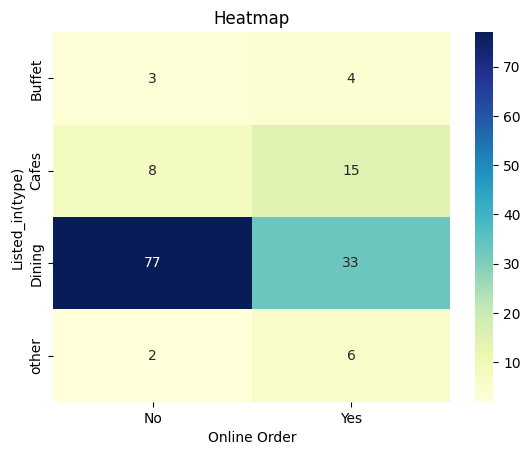

In [60]:
pivot_table = zomato_df.pivot_table(index='listed_in(type)', columns='online_order',aggfunc='size',fill_value=0)
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Heatmap')
plt.xlabel('Online Order')
plt.ylabel('Listed_in(type)')
plt.show()

### Conclusion: Dining restaturants primarly accepts online orders, whereas cafes prefer offline order, therefore this suggests that more people prefer orders in person at restuarants, but in cafes they prefer more online orders.